# Crop Disease Detection (Kaggle)
Simple Transfer Learning using Efficeintnet.

### Cell 1: Imports

In [1]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


### Cell 2: Dataset Paths
Finds train and valid folders automatically.

In [2]:
# Set base path
base_path = "/kaggle/input/new-plant-diseases-dataset"
if not os.path.exists(base_path):
    base_path = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset"

train_path = os.path.join(base_path, "New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train")
valid_path = os.path.join(base_path, "New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid")

# Fallback if subfolder structure is flat
if not os.path.exists(train_path):
    for root, dirs, files in os.walk(base_path):
        if "train" in dirs:
            train_path = os.path.join(root, "train")
            valid_path = os.path.join(root, "valid")
            break

print("Train folder:", train_path)
print("Valid folder:", valid_path)

Train folder: /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
Valid folder: /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid


### Cell 3: Load Data (Train & Validation)

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    image_size=(224, 224),
    batch_size=32
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Loaded {num_classes} classes successfully!")

Found 70295 files belonging to 38 classes.


I0000 00:00:1789742414.892219      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789742414.895431      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 17572 files belonging to 38 classes.
Loaded 38 classes successfully!


### Cell 4: Build Model (MobileNetV2 Transfer Learning)

In [10]:
### Cell 4: Build Model (EfficientNet-B0)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# 1. Load pre-trained EfficientNetB0
base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # Freeze backbone

# 2. Build model 
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")  # 38 classes
])

print("EfficientNet-B0 model built successfully!")

EfficientNet-B0 model built successfully!


### Cell 5: Compile & Train

In [11]:
### Cell 5: Compile & Train
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Save the best model automatically
callbacks = [
    ModelCheckpoint(
        "/kaggle/working/effnet_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,               # 15 epochs is plenty
    callbacks=callbacks
)

Epoch 1/15
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8446 - loss: 0.6049
Epoch 1: val_loss improved from None to 0.11224, saving model to /kaggle/working/effnet_model.keras

Epoch 1: finished saving model to /kaggle/working/effnet_model.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 129s 50ms/step - accuracy: 0.9237 - loss: 0.2722 - val_accuracy: 0.9626 - val_loss: 0.1122
Epoch 2/15
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9675 - loss: 0.0993
Epoch 2: val_loss improved from 0.11224 to 0.08584, saving model to /kaggle/working/effnet_model.keras

Epoch 2: finished saving model to /kaggle/working/effnet_model.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 90s 41ms/step - accuracy: 0.9709 - loss: 0.0871 - val_accuracy: 0.9697 - val_loss: 0.0858
Epoch 3/15
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9758 - loss: 0.0721
Epoch 3: val_loss did not improve from 0.08584
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 89s 40ms/step - accuracy: 0.9787 - loss: 0.0633 - val_accuracy: 0.969

In [12]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,556,183 (17.38 MB)

 Trainable params: 168,870 (659.65 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 337,742 (1.29 MB)

### Cell 6: Plot Accuracy

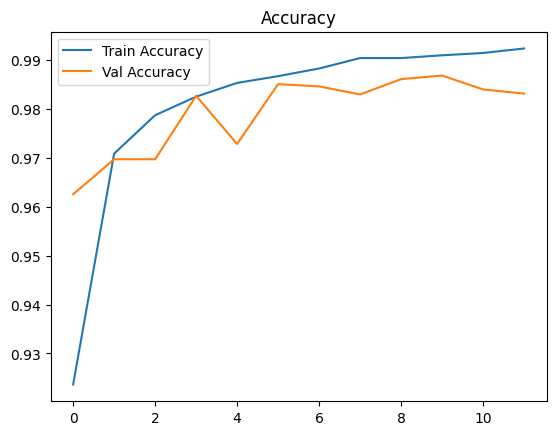

In [13]:
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy")
plt.legend()
plt.show()

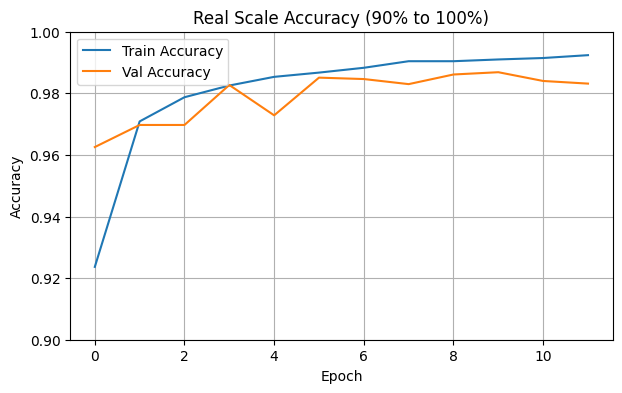

In [14]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Real Scale Accuracy (90% to 100%)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0.90, 1.0)  # <--- Fixes the misleading zoom!
plt.legend()
plt.grid(True)
plt.show()

### Cell 7: Save Model & Predict Leaf Image

In [15]:
import json

# 1. Save the model
model_save_path = "efficient.keras"  # or "/kaggle/working/crop_model.keras" if on Kaggle
model.save(model_save_path)
print(f"Model successfully saved to: {model_save_path}")

# 2. Save class labels to a JSON file
with open("class_names.json", "w") as f:
    json.dump(class_names, f)
print("Class names saved to: class_names.json")

Model successfully saved to: efficient.keras
Class names saved to: class_names.json


True Label: Tomato___Late_blight


2026-09-18 16:06:40.537235: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 16:06:40.672790: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 16:06:41.439918: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 16:06:41.575114: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 16:06:41.710797: E external/local_xla/xla/stream_

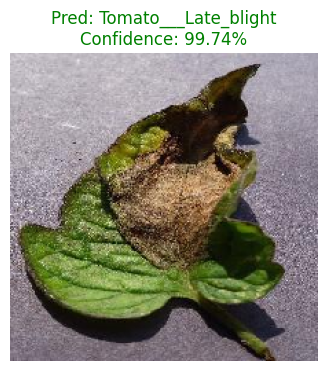

In [16]:
import numpy as np

def predict_leaf(img_path):
    # Load and preprocess image
    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img_arr = tf.keras.utils.img_to_array(img)
    img_arr = tf.expand_dims(img_arr, 0)  # Shape: (1, 224, 224, 3)

    # Predict
    preds = model.predict(img_arr, verbose=0)
    pred_idx = np.argmax(preds[0])
    confidence = preds[0][pred_idx] * 100
    predicted_label = class_names[pred_idx]

    # Display image with prediction
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"Pred: {predicted_label}\nConfidence: {confidence:.2f}%", color="green" if confidence > 80 else "red")
    plt.axis("off")
    plt.show()

# Pick a test image from the validation set and predict
sample_class = os.listdir(valid_path)[0]
sample_img_name = os.listdir(os.path.join(valid_path, sample_class))[0]
test_image_path = os.path.join(valid_path, sample_class, sample_img_name)

print(f"True Label: {sample_class}")
predict_leaf(test_image_path)

In [17]:
val_loss, val_acc = model.evaluate(val_ds)
print(f"Final Validation Loss: {val_loss:.4f}")
print(f"Final Validation Accuracy: {val_acc * 100:.2f}%")

550/550 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.9851 - loss: 0.0449
Final Validation Loss: 0.0449
Final Validation Accuracy: 98.51%


In [ ]:
model.summary()